# Generating GeoMAD composites

* **Products used:** 
[s2_l2a](https://explorer.digitalearth.africa/s2_l2a),
[ls8_sr](https://explorer.digitalearth.africa/ls8_sr)


## Background

Individual remote sensing images can be affected by noisy data, including clouds, cloud shadows, and haze. 
To produce cleaner images that can be compared more easily across time, we can create 'summary' images or 'composites' that combine multiple images into one image to reveal the median or 'typical' appearance of the landscape for a certain time period. 

One approach is to create a [geomedian](https://github.com/daleroberts/hdmedians). A `geomedian` is based on a high-dimensional statistic called the 'geometric median' [(Small 1990)](https://www.jstor.org/stable/1403809), which effectively trades a temporal stack of poor quality observations for a single high-quality pixel composite with reduced spatial noise [(Roberts et al. 2017)](https://ieeexplore.ieee.org/abstract/document/8004469). In contrast to a standard median, a geomedian maintains the relationship between spectral bands.  This allows us to conduct further analysis on the composite images just as we would on the original satellite images (e.g by allowing the calculation of common band indices, like NDVI).

DE Africa's GEoMAD product (**Geo**median and **M**edian **A**bsolute **D**eviations), in addition to containing geomedians of the surface relfectance bands, GeoMAD also includes three Median Absolute Deviation (MAD) layers. These are higher-order statistical measurements on variation relative to the geomedian. These layers can be used on their own or together with geomedian to gain insights about the land surface and understand its change over time.

All the data of the selected timeframe has to be loaded to compute a composite, so geomedians can be computationally intensive to calculate, especially over large areas or long timescales. To assist with such analyses, DE Africa hosts a number of pre-calculated geoMAD products:

* [Sentinel-2 annual GeoMAD](https://docs.digitalearthafrica.org/en/latest/data_specs/GeoMAD_specs.html) from 2017 to present, with product name `gm_s2_annual`
* [Sentinel-2 semi-annual (six-month) GeoMAD](https://explorer.digitalearth.africa/products/gm_s2_semiannual/extents) from 2019 to present, with product name `gm_s2_semiannual`
* [Landat annual GeoMAD](https://explorer.digitalearth.africa/products/gm_ls8_annual/extents) from 2013 to present, with product name `gm_ls8_annual`


This reduces the time and resource needed to calculate the geomedian if you are conducting analysis over an annual timescale. Instructions on how to use the geomedian from the Sentinel-2 GeoMAD can be found in the [Datasets/GeoMAD.ipynb](../Datasets/GeoMAD.ipynb) notebook.

For analysis on other timescales, such as investigating change over seasons, it is not possible to use the annual geomedian product. In those cases, it can be useful to calculate GeoMAD for that specific time period.

## Description
In this notebook we will take of time series of noisy satellite images and calculate a GeoMAD composite which is largely free of clouds and other noisy data.

GeoMAD computations are expensive in terms of memory, data bandwidth, and CPU usage. The ODC has a useful function, [geomedian_with_mads](https://github.com/opendatacube/odc-tools/blob/6c7a8bf9058d4e96ca27e5de21c7ff039338fc1c/libs/algo/odc/algo/_geomedian.py#L305) that allows [dask](https://docs.dask.org/en/latest/) to perform the computation in parallel across many threads to speed things up. In this notebook a `local dask cluster` is used, but the same approach should work using a larger, distributed dask cluster.

***


## Getting started
To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages

In [1]:
%matplotlib inline

import datacube
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from odc.algo import geomedian_with_mads
from odc.geo.geom import Geometry
from deafrica_tools.plotting import rgb
from deafrica_tools.datahandling import load_ard
from deafrica_tools.dask import create_local_dask_cluster
from deafrica_tools.areaofinterest import define_area

### Set up a dask cluster

This will help keep our memory use down and conduct the analysis in parallel. If you'd like to view the `dask dashboard`, click on the hyperlink that prints below the cell. You can use the dashboard to monitor the progress of calculations.


In [2]:
create_local_dask_cluster()

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/mpho.sadiki@digitalearthafrica.org/proxy/8787/status,
Dashboard: /user/mpho.sadiki@digitalearthafrica.org/proxy/8787/status,Workers: 1
Total threads: 4,Total memory: 26.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34409,Workers: 0
Dashboard: /user/mpho.sadiki@digitalearthafrica.org/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41955,Total threads: 4
Dashboard: /user/mpho.sadiki@digitalearthafrica.org/proxy/37917/status,Memory: 26.21 GiB
Nanny: tcp://127.0.0.1:42027,


### Connect to the datacube

In [3]:
dc = datacube.Datacube(app='Generating_geomedian_composites')

## Load Sentinel-2 from the datacube

Here we are loading in a timeseries of cloud-masked Sentinel-2 satellite images through the datacube API using the [load_ard](../Frequently_used_code/Using_load_ard.ipynb) function. 
This will provide us with some data to work with. To limit computation and memory this example uses only three optical bands (red, green, blue).

#### Select location
To define the area of interest, there are two methods available:

1. By specifying the latitude, longitude, and buffer. This method requires you to input the central latitude, central longitude, and the buffer value in square degrees around the center point you want to analyze. For example, `lat = 10.338`, `lon = -1.055`, and `buffer = 0.1` will select an area with a radius of 0.1 square degrees around the point with coordinates (10.338, -1.055).

2. By uploading a polygon as a `GeoJSON or Esri Shapefile`. If you choose this option, you will need to upload the geojson or ESRI shapefile into the Sandbox using Upload Files button <img align="top" src="../Supplementary_data/upload_files_icon.png"> in the top left corner of the Jupyter Notebook interface. ESRI shapefiles must be uploaded with all the related files `(.cpg, .dbf, .shp, .shx)`. Once uploaded, you can use the shapefile or geojson to define the area of interest. Remember to update the code to call the file you have uploaded.

To use one of these methods, you can uncomment the relevant line of code and comment out the other one. To comment out a line, add the `"#"` symbol before the code you want to comment out. By default, the first option which defines the location using latitude, longitude, and buffer is being used.

In [4]:
# Set the area of interest

# Method 1: Specify the latitude, longitude, and buffer
aoi = define_area(lat=-31.535, lon=18.2702, buffer=0.035)

# Method 2: Use a polygon as a GeoJSON or Esri Shapefile. 
# aoi = define_area(vector_path='aoi.shp')

#Create a geopolygon and geodataframe of the area of interest
geopolygon = Geometry(aoi["features"][0]["geometry"], crs="epsg:4326")
geopolygon_gdf = gpd.GeoDataFrame(geometry=[geopolygon], crs=geopolygon.crs)

# Get the latitude and longitude range of the geopolygon
lat_range = (geopolygon_gdf.total_bounds[1], geopolygon_gdf.total_bounds[3])
lon_range = (geopolygon_gdf.total_bounds[0], geopolygon_gdf.total_bounds[2])

# Create a reusable query
query = {
    'x': lon_range,
    'y': lat_range,
    'time': ('2019-01', '2019-12'),
    'measurements': ['green',
                     'red',
                     'blue'],
    'resolution': (-10, 10),
    'group_by': 'solar_day',
    'output_crs': 'EPSG:6933'
}

Compared to the typical use of `load_ard` which by default returns data with floating point numbers containing `NaN` (i.e. `float32`), in this example we will set the `dtype` to `'native'`. 
This will keep our data in its original integer data type (i.e. `Int16`), with nodata values marked with `-999`.
Doing this will halve the amount of memory our data takes up, which can be extremely valuable when conducting large-scale analyses.

In [5]:
# Load available data
ds = load_ard(dc=dc, 
              products=['s2_l2a'],
              dask_chunks={'x':1000, 'y':1000},
              mask_filters=(['opening',5], ['dilation',5]), #improve cloud mask
              dtype='native',
              **query)

# Print output data
print(ds)

Using pixel quality parameters for Sentinel 2
Finding datasets
    s2_l2a
Applying morphological filters to pq mask (['opening', 5], ['dilation', 5])
Applying pixel quality/cloud mask
Returning 72 time steps as a dask array
<xarray.Dataset> Size: 224MB
Dimensions:      (time: 72, y: 765, x: 677)
Coordinates:
  * time         (time) datetime64[ns] 576B 2019-01-04T08:59:00 ... 2019-12-3...
  * y            (y) float64 6kB -3.824e+06 -3.824e+06 ... -3.831e+06 -3.831e+06
  * x            (x) float64 5kB 1.759e+06 1.759e+06 ... 1.766e+06 1.766e+06
    spatial_ref  int32 4B 6933
Data variables:
    green        (time, y, x) uint16 75MB dask.array<chunksize=(1, 765, 677), meta=np.ndarray>
    red          (time, y, x) uint16 75MB dask.array<chunksize=(1, 765, 677), meta=np.ndarray>
    blue         (time, y, x) uint16 75MB dask.array<chunksize=(1, 765, 677), meta=np.ndarray>
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref


/opt/venv/lib/python3.12/site-packages/odc/algo/_masking.py:425: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = op(mask, _disk(radius, mask.ndim))
/opt/venv/lib/python3.12/site-packages/odc/algo/_masking.py:425: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  mask = op(mask, _disk(radius, mask.ndim))
/opt/venv/lib/python3.12/site-packages/odc/algo/_masking.py:425: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = op(mask, _disk(radius, mask.ndim))
/opt/venv/lib/python3.12/site-packages/odc/algo/_masking.py:425: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in versio

## Plot timesteps in true colour

To visualise the data, use the pre-loaded `rgb` utility function to plot a true colour image for a series of timesteps. 
Black areas indicate where clouds or other invalid pixels in the image have been set to `-999` to indicate no data.

The code below will plot three timesteps of the time series we just loaded.


/opt/venv/lib/python3.12/site-packages/odc/algo/_masking.py:425: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = op(mask, _disk(radius, mask.ndim))
/opt/venv/lib/python3.12/site-packages/odc/algo/_masking.py:425: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  mask = op(mask, _disk(radius, mask.ndim))
/opt/venv/lib/python3.12/site-packages/odc/algo/_masking.py:425: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = op(mask, _disk(radius, mask.ndim))
/opt/venv/lib/python3.12/site-packages/odc/algo/_masking.py:425: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in versio

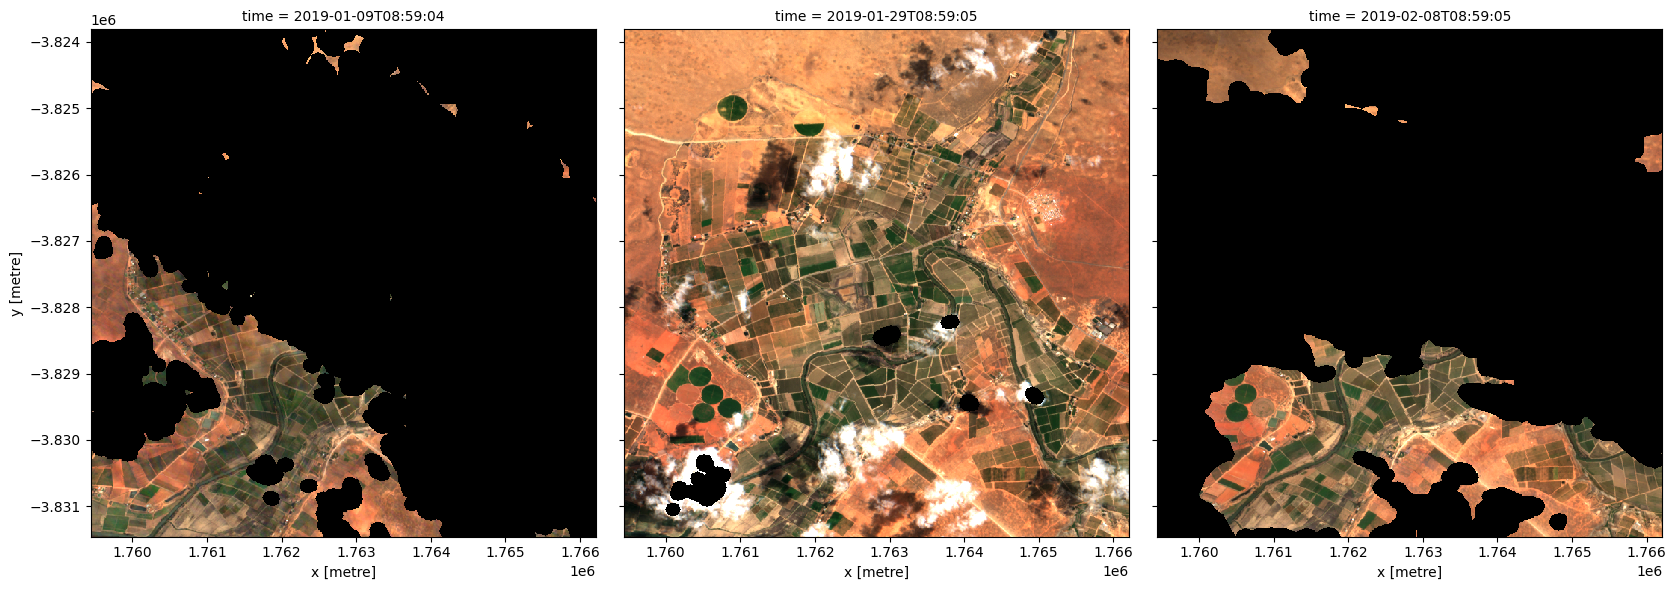

In [6]:
# Set the timesteps to visualise
timesteps = [1, 5, 7]

# Generate RGB plots at each timestep
rgb(ds, index=timesteps)


## Generate a geomedian

As you can see above, most satellite images will have at least some areas masked out due to clouds or other interference between the satellite and the ground. 
Running the `geomedian_with_mads` function will generate a geomedian composite by combining all the observations in our `xarray.Dataset` into a single, complete (or near complete) image representing the geometric median of the time period.

> **Note:** Because our data was lazily loaded with `dask`, the geomedian algorithm itself will not be triggered until we call the `.compute()` method in the next step.

In [7]:
# geomedian = int_geomedian(ds)
geomedian = geomedian_with_mads(ds,
                               compute_mads=False,
                               compute_count=False,
                               reshape_strategy="yxbt"  # Instead of default "mem"
                               )

### Run the computation

The `.compute()` method will trigger the computation of the geomedian algorithm above.
This will take about a few minutes to run; view the `dask dashboard` to check the progress.

In [8]:
%%time
geomedian = geomedian.compute()

/opt/venv/lib/python3.12/site-packages/odc/algo/_masking.py:425: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = op(mask, _disk(radius, mask.ndim))
/opt/venv/lib/python3.12/site-packages/odc/algo/_masking.py:425: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  mask = op(mask, _disk(radius, mask.ndim))
/opt/venv/lib/python3.12/site-packages/odc/algo/_masking.py:425: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = op(mask, _disk(radius, mask.ndim))
/opt/venv/lib/python3.12/site-packages/odc/algo/_masking.py:425: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in versio

CPU times: user 2.83 s, sys: 338 ms, total: 3.17 s
Wall time: 1min 7s


If we print our result, you will see that the `time` dimension has now been removed and we are left with a single image that represents the geometric median of all the satellite images in our initial time series:

In [9]:
geomedian

<xarray.Dataset> Size: 3MB
Dimensions:  (y: 765, x: 677)
Coordinates:
  * y        (y) float64 6kB -3.824e+06 -3.824e+06 ... -3.831e+06 -3.831e+06
  * x        (x) float64 5kB 1.759e+06 1.759e+06 ... 1.766e+06 1.766e+06
Data variables:
    green    (y, x) uint16 1MB 1243 1303 1330 1320 1240 ... 1496 1478 1384 1294
    red      (y, x) uint16 1MB 1900 1992 2036 2018 1889 ... 2533 2525 2362 2235
    blue     (y, x) uint16 1MB 732 777 799 788 736 693 ... 894 912 898 824 773
Attributes:
    units:         1
    nodata:        0
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

### Plot the geomedian composite

Plotting the result, we can see that the geomedian image is much more complete than any of the individual images. 
We can also use this data in downstream analysis as the relationships between the spectral bands are maintained by the geometric median statistic.


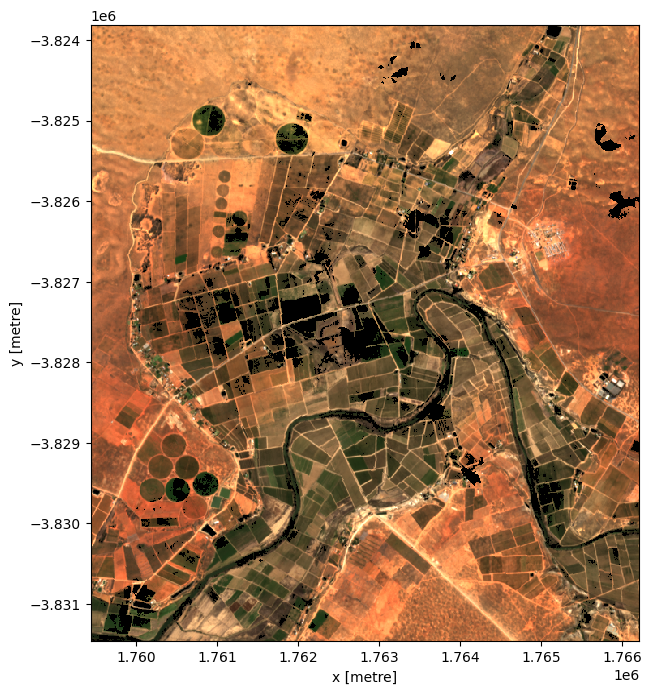

In [10]:
# Plot the result
rgb(geomedian, size=8)


## Generate median absolute deviations

In addition to running a geomedian composite, which will return the median observations for each band, we can also compute the variation that each pixel undergoes during the time series. The `geomedian_with_mads` function returns three measures of variability: the spectral median absolute deviation (`smad`), the Euclidian median absolute deviation (`emad`), and the bray-curtis median absolute deviation (`bcmad`).

To compute the three measures of variability simply pass `compute_mads=True` to the `geomedian_with_mads` function. This function also supports returning the `count`, which returns the number of clear observations for each pixel.

In [11]:
geomads = geomedian_with_mads(ds,
                              compute_mads=True,
                              compute_count=True,
                              reshape_strategy="yxbt"  # Instead of default "mem"
                             )

geomads = geomads.compute()
print(geomads)

<xarray.Dataset> Size: 10MB
Dimensions:  (y: 765, x: 677)
Coordinates:
  * y        (y) float64 6kB -3.824e+06 -3.824e+06 ... -3.831e+06 -3.831e+06
  * x        (x) float64 5kB 1.759e+06 1.759e+06 ... 1.766e+06 1.766e+06
Data variables:
    green    (y, x) uint16 1MB 1243 1303 1330 1320 1240 ... 1496 1478 1384 1294
    red      (y, x) uint16 1MB 1900 1992 2036 2018 1889 ... 2533 2525 2362 2235
    blue     (y, x) uint16 1MB 732 777 799 788 736 693 ... 894 912 898 824 773
    smad     (y, x) float32 2MB 0.0001308 0.0001117 ... 0.0002928 0.0002812
    emad     (y, x) float32 2MB 824.4 771.3 780.8 ... 913.3 1.12e+03 1.326e+03
    bcmad    (y, x) float32 2MB 0.1552 0.143 0.1391 ... 0.1322 0.1671 0.1991
    count    (y, x) uint16 1MB 72 72 72 72 72 72 72 72 ... 72 72 72 72 72 72 72
Attributes:
    units:         1
    nodata:        0
    crs:           EPSG:6933
    grid_mapping:  spatial_ref


### Plot median absolute deviations and clear count

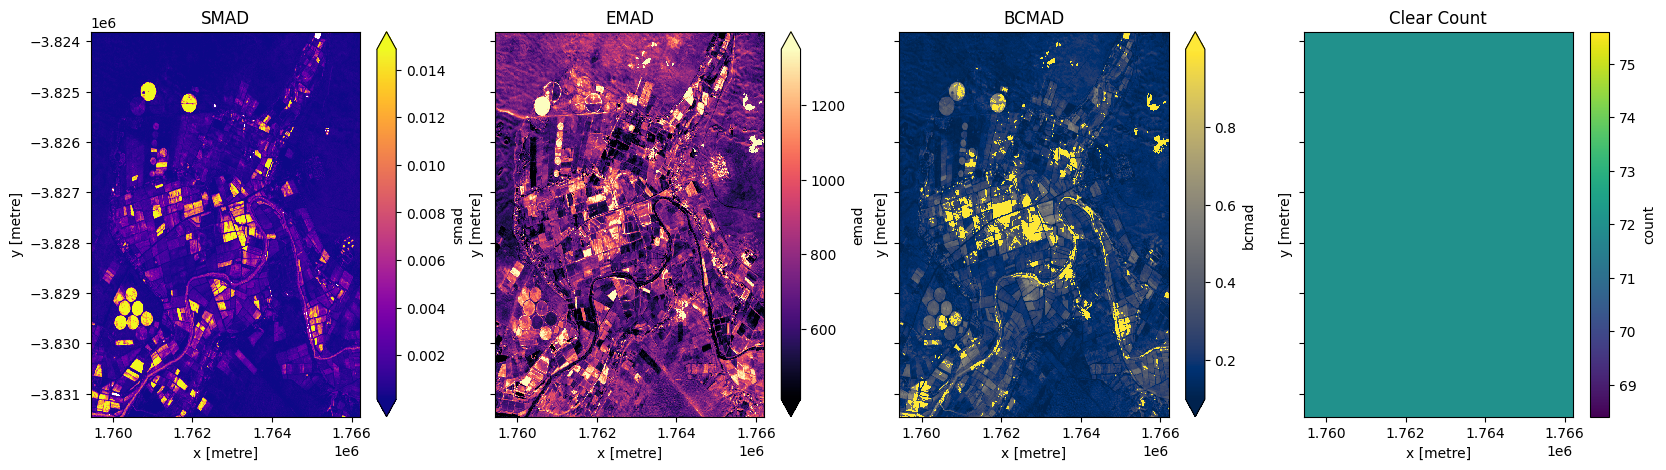

In [12]:
fig,ax=plt.subplots(1,4, sharey=True, figsize=(20,5))
geomads['smad'].plot(ax=ax[0], cmap='plasma', robust=True)
geomads['emad'].plot(ax=ax[1], cmap='magma', robust=True)
geomads['bcmad'].plot(ax=ax[2], cmap='cividis', robust=True)
geomads['count'].plot(ax=ax[3], cmap='viridis', robust=True)
ax[0].set_title('SMAD')
ax[1].set_title('EMAD')
ax[2].set_title('BCMAD')
ax[3].set_title('Clear Count');

### Running GeoMADs on grouped or resampled timeseries

In the notebook [Generating composites](./Generating_composites.ipynb), built in functions such as `mean` and `median` are run on timeseries data that has been resampled or grouped.  
We can use the same techniques with the geomedian function.

#### Resampling 

First we will split the timeseries into the desired groups.
Resampling can be used to create a new set of times at regular intervals:

 * `grouped = da_scaled.resample(time=1M)`
 
    * `'nD'` - number of days (e.g. `'7D'` for seven days)
    * `'nM'` - number of months (e.g. `'6M'` for six months)
    * `'nY'` - number of years (e.g. `'2Y'` for two years)

#### Group By
Grouping works by looking at part of the date, but ignoring other parts. 
For instance, `'time.month'` would group together all January data together, no matter what year it is from.

 * `grouped = da_scaled.groupby('time.month')`
 
     * `'time.day'` - groups by the day of the month (1-31)
     * `'time.dayofyear'` - groups by the day of the year (1-365)
     * `'time.week'` - groups by week (1-52) 
     * `'time.month'` - groups by the month (1-12)
     * `'time.season'` - groups into 3-month seasons:
         - `'DJF'` December, Jaunary, February
         - `'MAM'` March, April, May
         - `'JJA'` June, July, August
         - `'SON'` September, October, November
     * `'time.year'` - groups by the year
 
Here we will resample into three two-monthly groups (`'2M'`), with the group starting at the start of the month (represented by the `'S'` at the end).

In [13]:
grouped = ds.resample(time='2MS')
grouped

<DatasetResample, grouped over 1 grouper(s), 6 groups in total:
    '__resample_dim__': TimeResampler('__resample_dim__'), 6/6 groups with labels 2019-01-01, ..., 2019-11-01>

Now we will apply the `geomedian_with_mads` function to each resampled group using the `map` method.

Instead of calling `geomedian_with_mads(ds)` on the entire array, we pass the `geomedian_with_mads` function to `map` to apply it separately to each resampled group.

In [14]:
geomedian_grouped = grouped.map(geomedian_with_mads, reshape_strategy="yxbt") # Instead of default "mem"

We can now trigger the computation, and watch progress using the dask dashboard.

In [15]:
geomedian_grouped = geomedian_grouped.compute()

We can plot the output geomedians, and see the change in the landscape over the year:

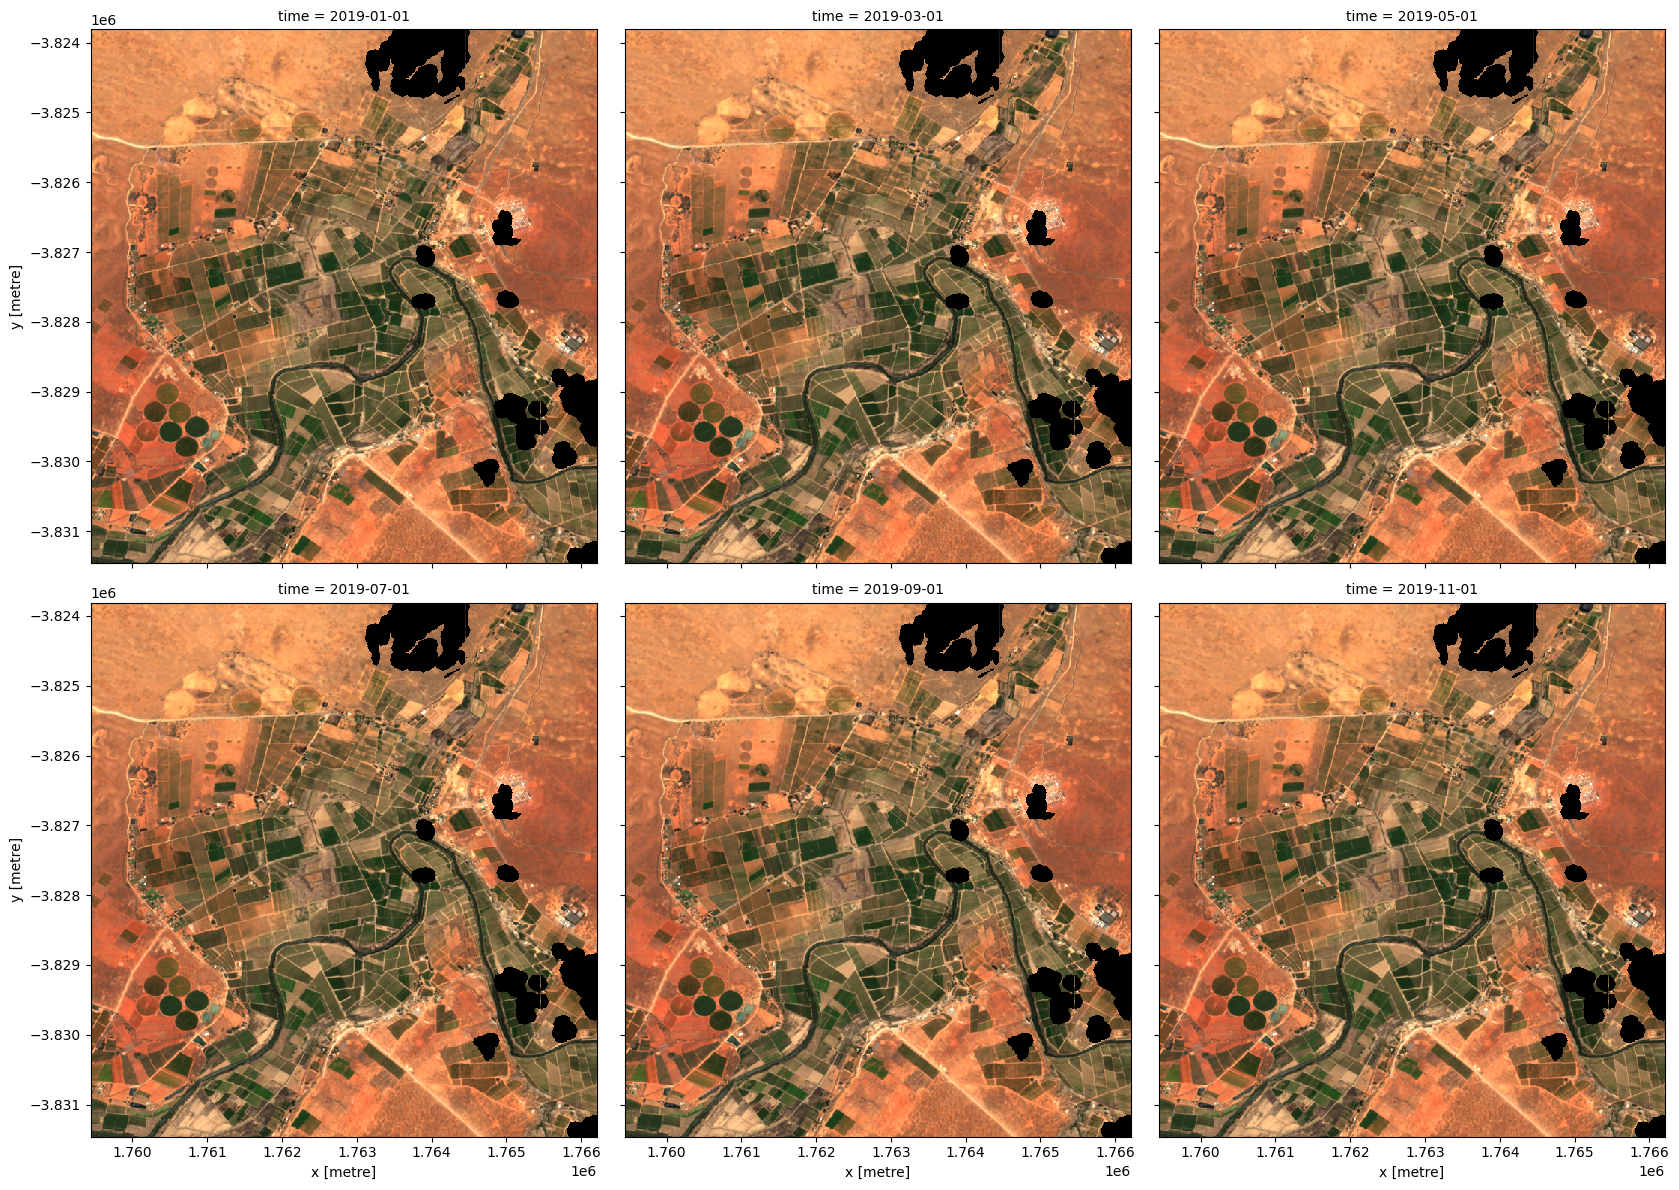

In [16]:
rgb(geomedian_grouped, col='time', col_wrap=3)

## Advanced: GeoMADs on Landsat data

Below we calculate GeoMADs using Landsat 8.  For the GeoMAD to match Sentinel-2, we need to take one extra step. Landsat surface relfetance data is scaled from 0 to 1, while Sentinel-2 data is scaled from 0-10,000. For the two datasets to match, we need to multiply the Landsat bands by 10,000 (this will make the geoMADs produced in this notebook match the `gm_ls8_annual` dataset available in the datacube). The bands `bcmad` and `smad` do _not_ need to be mulitplied by 10,000.



In [17]:
# Load available data for Landsat 8
ds = load_ard(dc=dc, 
              x=lon_range,
              y=lat_range,
              time=('2019-01', '2019-12'),
              measurements=['green','red','blue'],
              products=['ls8_sr'],
              dask_chunks={'x':1000, 'y':1000},
              mask_filters=(['opening',3], ['dilation',3]), #improve cloud mask
              resolution=(-30,30),
              group_by='solar_day',
              output_crs='EPSG:6933'
             )

# Print output data
print(ds)

Using pixel quality parameters for USGS Collection 2
Finding datasets
    ls8_sr
Applying morphological filters to pq mask (['opening', 3], ['dilation', 3])
Applying pixel quality/cloud mask
Re-scaling Landsat C2 data
Returning 23 time steps as a dask array
<xarray.Dataset> Size: 16MB
Dimensions:      (time: 23, y: 256, x: 226)
Coordinates:
  * time         (time) datetime64[ns] 184B 2019-01-08T08:40:51.853294 ... 20...
  * y            (y) float64 2kB -3.824e+06 -3.824e+06 ... -3.831e+06 -3.831e+06
  * x            (x) float64 2kB 1.759e+06 1.759e+06 ... 1.766e+06 1.766e+06
    spatial_ref  int32 4B 6933
Data variables:
    green        (time, y, x) float32 5MB dask.array<chunksize=(1, 256, 226), meta=np.ndarray>
    red          (time, y, x) float32 5MB dask.array<chunksize=(1, 256, 226), meta=np.ndarray>
    blue         (time, y, x) float32 5MB dask.array<chunksize=(1, 256, 226), meta=np.ndarray>
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref


/opt/venv/lib/python3.12/site-packages/odc/algo/_masking.py:425: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = op(mask, _disk(radius, mask.ndim))
/opt/venv/lib/python3.12/site-packages/odc/algo/_masking.py:425: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  mask = op(mask, _disk(radius, mask.ndim))
/opt/venv/lib/python3.12/site-packages/odc/algo/_masking.py:425: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = op(mask, _disk(radius, mask.ndim))
/opt/venv/lib/python3.12/site-packages/odc/algo/_masking.py:425: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in versio

### Calculate GeoMADs on the Landsat data

In [18]:
geomads = geomedian_with_mads(ds,  reshape_strategy="yxbt", compute_mads=True, compute_count=True).compute() # Instead of default "mem"
print(geomads)


<xarray.Dataset> Size: 2MB
Dimensions:  (y: 256, x: 226)
Coordinates:
  * y        (y) float64 2kB -3.824e+06 -3.824e+06 ... -3.831e+06 -3.831e+06
  * x        (x) float64 2kB 1.759e+06 1.759e+06 ... 1.766e+06 1.766e+06
Data variables:
    green    (y, x) float32 231kB 0.1419 0.1439 0.1352 ... 0.1597 0.1509 0.1506
    red      (y, x) float32 231kB 0.2158 0.2185 0.2056 ... 0.2627 0.2512 0.2384
    blue     (y, x) float32 231kB 0.07643 0.07741 0.07278 ... 0.07561 0.07653
    smad     (y, x) float32 231kB 1.878e-05 3.331e-05 ... 0.0002164 0.0003216
    emad     (y, x) float32 231kB 0.03394 0.02932 0.03075 ... 0.02122 0.01755
    bcmad    (y, x) float32 231kB 0.05951 0.05521 0.0572 ... 0.03528 0.03135
    count    (y, x) uint16 116kB 15 15 14 14 14 14 14 ... 14 14 14 14 14 14 14
Attributes:
    units:         1
    nodata:        0
    crs:           EPSG:6933
    grid_mapping:  spatial_ref


### Multiply bands by 10,000 to match Sentinel-2

In [19]:
exclude = ['bcmad', 'smad', 'count']

for band in geomads.data_vars:
    if band not in exclude:
        geomads[band] = geomads[band]*10000

### Plot the Landsat GeoMAD

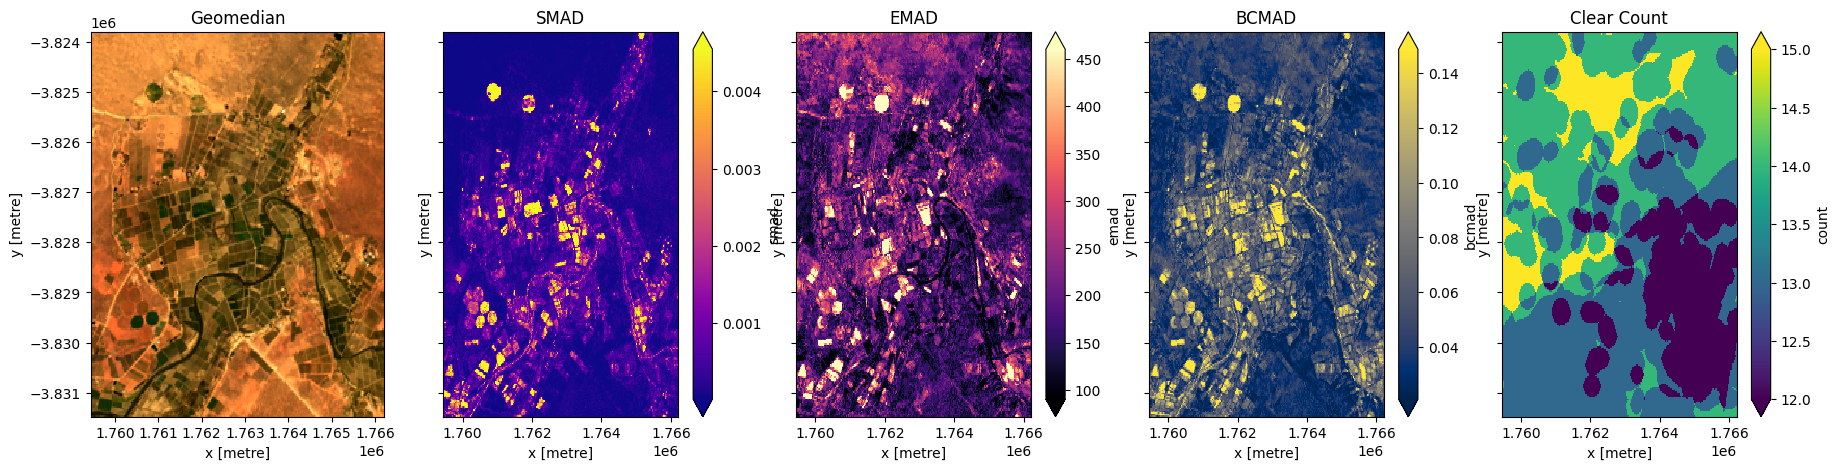

In [20]:
fig,ax=plt.subplots(1,5, sharey=True, figsize=(22,5))
rgb(geomads, ax=ax[0])
geomads['smad'].plot(ax=ax[1], cmap='plasma', robust=True)
geomads['emad'].plot(ax=ax[2], cmap='magma', robust=True)
geomads['bcmad'].plot(ax=ax[3], cmap='cividis', robust=True)
geomads['count'].plot(ax=ax[4], cmap='viridis', robust=True)
ax[0].set_title('Geomedian')
ax[1].set_title('SMAD')
ax[2].set_title('EMAD')
ax[3].set_title('BCMAD')
ax[4].set_title('Clear Count');


***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Slack channel](http://slack.opendatacube.org/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

**Compatible datacube version:**

In [21]:
print(datacube.__version__)

1.9.13


**Last Tested:**

In [22]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2026-04-08'